In [1]:
import polars as pl
from pathlib import Path

RAW = Path("../data/raw")
pl.Config(fmt_str_lengths=70, tbl_rows=12, tbl_width_chars=180)

train = pl.scan_parquet(RAW / "train.parquet")       
bench_q = pl.read_parquet(RAW / "benchmark_queries.parquet")
bench_i = pl.scan_parquet(RAW / "benchmark_items.parquet")

## посмотрим что лежит в данных

In [2]:
for name, lf in [("train", train), ("benchmark_queries", bench_q.lazy()), ("benchmark_items", bench_i)]:
    schema = lf.collect_schema()
    n_rows = lf.select(pl.len()).collect().item()
    print(f"{name} {n_rows} строк {len(schema)} колонок")

print()
print("колонки трейн")
for col, dtype in train.collect_schema().items():
    side = "запрос " if col.startswith("search_") else "объявл"
    print(f"{side}  {col} {dtype}")

train 497673 строк 19 колонок
benchmark_queries 2452 строк 6 колонок
benchmark_items 189212 строк 14 колонок

колонки трейн
запрос   search_query String
запрос   search_location_id Int64
запрос   search_is_delivery_search Int32
запрос   search_infm_params_text String
запрос   search_category Int64
объявл  item_title_raw String
объявл  item_rating_reviews_count Float64
объявл  item_rating Float64
объявл  item_price Decimal(precision=27, scale=15)
объявл  item_microcat_id Int64
объявл  item_longitude Decimal(precision=18, scale=15)
объявл  item_location_id Int64
объявл  item_latitude Decimal(precision=17, scale=15)
объявл  item_is_phone_hidden Boolean
объявл  item_is_message_forbidden Boolean
объявл  item_infm_params_text String
объявл  item_id String
объявл  item_description_raw String
объявл  item_category_id Int64


In [3]:
col = train.select("search_category").collect().unique()
col

search_category
i64
0
81
114
10


## смотрим пары из треййна


In [4]:
def show_row(df: pl.DataFrame, i: int, width: int = 130) -> None:
    for col in df.columns:
        val = df[col][i]
        if val is None or (isinstance(val, str) and not val.strip()):
            shown = "пусто"
        else:
            shown = str(val)
        print(f"{col} │ {shown}")


head = train.head(3).collect()
for i in range(len(head)):
    print(f"пара #{i}")
    show_row(head, i)
    print()

пара #0
search_query │ скупка телевизоров
search_location_id │ 652430
search_is_delivery_search │ 0
search_infm_params_text │ пусто
search_category │ 114
item_title_raw │ Скупка б/у техники
item_rating_reviews_count │ 91.0
item_rating │ 4.989010989010989
item_price │ 1.000000000000000
item_microcat_id │ 2303374
item_longitude │ 39.712818145751953
item_location_id │ 652430
item_latitude │ 54.629230499267578
item_is_phone_hidden │ True
item_is_message_forbidden │ False
item_infm_params_text │ Вид услуги Место оказания услуг Первомайский пр-т, 66 Тип стоимости за услугу Работаете с юрлицами и ИП Опыт работы 10 лет и больше Гарантия на выполнение работ Как вы работаете У себя Предоплата Рабочие дни Понедельник Рабочие дни Вторник Рабочие дни Среда Рабочие дни Четверг Рабочие дни Пятница Рабочие дни Суббота Рабочие дни Воскресенье Выезд к клиенту
item_id │ e8b685dffe1a408e
item_description_raw │ Скупаю практически любую современную новую и б/у технику(обязательно рабочую), до 80% от рыночно

уже видно главное. запрос, два-три слова. объявление, заголовок плюс описание, написанное живым человеком с эмодзи и абзацами. матчить придется короткий запрос против длинного зашумленного текста

и еще: в примерах search_location_id совпадает с item_location_id. услуги локальны, это должен быть сильный признак

## запросы 

In [5]:
print("запросов", len(bench_q), "все query_id уникальны", bench_q["query_id"].n_unique() == len(bench_q))
bench_q.head(8)

запросов 2452 все query_id уникальны True


query_id,search_query,search_location_id,search_is_delivery_search,search_infm_params_text,search_category
str,str,i64,i32,str,i64
"""70DfDUpwjxB4lzFd""","""перевозки владикавказ тбилиси""",649820,0,"""""",114
"""JTrdTaZJvSiLPkXj""","""обзвон по базе""",107620,0,"""Вид услуги Деловые услуги""",114
"""LZCZNoVG4AFUkVRJ""","""липоредукция подбородка""",637640,0,"""Вид услуги Красота, здоровье""",114
"""660ac9QVtXkRxZC3""","""подъемник 4 х стоечный""",662810,0,"""""",114
"""YgHcM9MVbxKnxD1e""","""монтаж видеодомофонов""",642790,0,"""""",114
"""Fn8uGfYsaUS86ak6""","""боевое самбо""",659880,0,"""Тип услуги Дизайн, рисование Вид услуги Обучение, курсы""",114
"""u4hftjenWqHZoMep""","""услуги бухгалтера для ип""",633080,0,"""Вид услуги Деловые услуги Тип услуги Бухгалтерия, финансы""",114
"""2Ysms04CH0JxFR7M""","""бригада по установке забора из профнастила""",631870,0,"""""",114


## объявления

In [6]:
corpus_head = bench_i.select("item_id", "item_title_raw", "item_category_id", "item_microcat_id", "item_price", "item_rating", "item_rating_reviews_count", "item_location_id").head(8).collect()
corpus_head

item_id,item_title_raw,item_category_id,item_microcat_id,item_price,item_rating,item_rating_reviews_count,item_location_id
str,str,i64,i64,"decimal[27,15]",f64,f64,i64
"""111eb8b979577d79""","""Ремонт/выкуп компьют. и ноутбуков с выездом на дом""",114,2097573,500.000000000000000,5.0,57.0,631060
"""75fc8e10f5a66fc4""","""Обучение ребенка чтению""",114,86453,900.000000000000000,5.0,7.0,631870
"""3f6ae81704565b9c""","""Афрокудри 5+""",114,86467,1000.000000000000000,5.0,14.0,628500
"""0618dec37a59a21a""","""Монтаж малых архитектурных форм""",114,2058739,5000.000000000000000,5.0,2.0,637640
"""13da2c81574677ed""","""Репетитор по истории 10 класс ЕГЭ""",114,86456,1500.000000000000000,5.0,19.0,624850
"""285fdc0b02a11b17""","""Ремонт посудомоечных машин с выездом на дом""",114,2169974,370.000000000000000,4.853175,252.0,637640
"""ac2beb33ad106198""","""Подарок на праздник - Песня на заказ""",114,2302856,400.000000000000000,4.953307,257.0,662150
"""c076e5c5ad898e1b""","""Пух перо""",114,2301617,1000.000000000000000,4.111111,9.0,655360


In [7]:
one = bench_i.head(1).collect()
show_row(one, 0, width=400)

item_title_raw │ Ремонт/выкуп компьют. и ноутбуков с выездом на дом
item_rating_reviews_count │ 57.0
item_rating │ 5.0
item_price │ 500.000000000000000
item_microcat_id │ 2097573
item_longitude │ 42.047193961004901
item_location_id │ 631060
item_latitude │ 44.228180450924000
item_is_phone_hidden │ False
item_is_message_forbidden │ False
item_infm_params_text │ Вид услуги Компьютерная помощь Место оказания услуг пр-т Ленина Тип стоимости за услугу Начальная цена График работы от 34200 График работы до 82800 Время работы, с 09:30 Время работы, до 23:00 Начальная цена Тип стоимости за услугу Стоимость 500 Услуга Диагностика компьютера Начальная цена Тип стоимости за услугу Стоимость 500 Услуга Начальная цена Тип стоимости за услугу Стоимость 500 Услуга Начальная цена Тип стоимости за услугу Стоимость 1000 Услуга Замена термопасты Начальная цена Тип стоимости за услугу Стоимость 1000 Услуга Ремонт после залития Начальная цена Тип стоимости за услугу Стоимость 500 Услуга Чистка системы охла

## разбираем некоотрые фичи


попробуем правильно распарсить фичи *_infm_params_text

In [8]:
print("запрос")
for v in (bench_q.filter(pl.col("search_infm_params_text").str.strip_chars() != "") ["search_infm_params_text"].head(6)):
    print(v)

print()
print("айтем")
for v in (bench_i.select("item_infm_params_text").head(3).collect()["item_infm_params_text"]):
    print(v)

запрос
Вид услуги Деловые услуги
Вид услуги Красота, здоровье
Тип услуги Дизайн, рисование Вид услуги Обучение, курсы
Вид услуги Деловые услуги Тип услуги Бухгалтерия, финансы
Вид услуги Оборудование, производство
Вид услуги Оборудование, производство

айтем
Вид услуги Компьютерная помощь Место оказания услуг пр-т Ленина Тип стоимости за услугу Начальная цена График работы от 34200 График работы до 82800 Время работы, с 09:30 Время работы, до 23:00 Начальная цена Тип стоимости за услугу Стоимость 500 Услуга Диагностика компьютера Начальная цена Тип стоимости за услугу Стоимость 500 Услуга Начальная цена Тип стоимости за услугу Стоимость 500 Услуга Начальная цена Тип стоимости за услугу Стоимость 1000 Услуга Замена термопасты Начальная цена Тип стоимости за услугу Стоимость 1000 Услуга Ремонт после залития Начальная цена Тип стоимости за услугу Стоимость 500 Услуга Чистка системы охлаждения Начальная цена Тип стоимости за услугу Стоимость 500 Услуга Установка базовых драйверов Начальная

In [9]:
# насколько часто фильтры вообще заданы
empty_train = train.select(
    (pl.col("search_infm_params_text").str.strip_chars() == "").mean()
).collect().item()
empty_bench = (bench_q["search_infm_params_text"].str.strip_chars() == "").mean()

print("пустой search_infm_params_text: трейн", round(empty_train * 100), "% бенчмарк", round(empty_bench * 100), "%")

пустой search_infm_params_text: трейн 33 % бенчмарк 63 %


## холодный ли корпус

главный вопрос ко всем данным сразу. если объявления из трейна и объявления из корпуса, в основном одни и те же, работает все коллаборативное: обучаемые эмбеддинги айтемов, статистика этот запрос -> этот item_id. если нет, корпус для нас холодный, и остается только контент

In [10]:
train_items = set(train.select("item_id").unique().collect()["item_id"])
corpus_items = set(bench_i.select("item_id").unique().collect()["item_id"])
shared_items = train_items & corpus_items

print(f"уникальных item_id в трейне {len(train_items)}")
print(f"уникальных item_id в корпусе {len(corpus_items)}")
print("общих", len(shared_items), "это", round(100 * len(shared_items) / len(corpus_items), 1), "% корпуса")

уникальных item_id в трейне 344825
уникальных item_id в корпусе 189212
общих 18142 это 9.6 % корпуса


In [11]:
# то же для текстов запросов
train_queries = set(train.select("search_query").unique().collect()["search_query"])
bench_queries = set(bench_q["search_query"])
shared_queries = train_queries & bench_queries

print("уникальных текстов запросов в трейне", len(train_queries))
print("в бенчмарке", len(bench_queries))
print("общих", len(shared_queries), "это", round(100 * len(shared_queries) / len(bench_queries), 1), "% бенчмарковых")

уникальных текстов запросов в трейне

 74529
в бенчмарке 2452
общих 907 это 37.0 % бенчмарковых


девять процентов корпуса. То есть **корпус холодный**: связь запрос -> конкретный item_id из трейна почти никуда не переносится, обучаемые эмбеддинги объявлений здесь бесполезны, для 90% корпуса их просто не из чего выучить

по запросам картина мягче: чуть больше трети текстов встречались в трейне. Это не способ решить задачу, но подспорье для той части запросов, которые повторяются

## сколько правильных ответов на запрос

от этого зависит, насколько метрика прощает ошибки. считаю запрос уникальным по всем пяти его признакам а не только по тексту: один и тот же текст в разных городах и с разными фильтрами, это разные запросы

уникальных запросов в трейне 354463
релевантных на запрос: в среднем 1.32 медиана 1.0 максимум 278


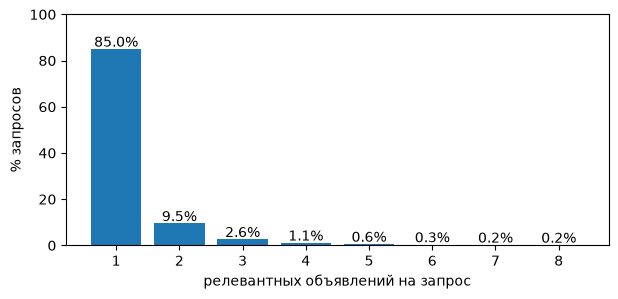

In [12]:
import matplotlib.pyplot as plt

per_query = (train.group_by("search_query", "search_location_id", "search_is_delivery_search", "search_infm_params_text", "search_category") .agg(pl.col("item_id").n_unique().alias("n_relevant")).collect())

print("уникальных запросов в трейне", len(per_query))
print("релевантных на запрос: в среднем", round(per_query["n_relevant"].mean(), 2), "медиана", per_query["n_relevant"].median(), "максимум", per_query["n_relevant"].max())

dist = per_query["n_relevant"].value_counts().sort("n_relevant").head(8)
share = dist["count"] / len(per_query) * 100

plt.figure(figsize=(7, 3))
plt.bar(dist["n_relevant"], share)
for x, y in zip(dist["n_relevant"], share):
    plt.text(x, y + 1, str(round(y, 1)) + "%", ha="center")
plt.xlabel("релевантных объявлений на запрос")
plt.ylabel("% запросов")
plt.ylim(0, 100)
plt.show()

у 85% запросов правильный ответ ровно один. значит Recall@50 здесь почти совпадает с долей запросов, где мы поймали нужное объявление, метрика бинарная по сути, промах стоит целый запрос

## гео и категории

два кандидата в фильтры, которые могли бы сузить корпус перед текстовым матчем. Проверяю оба

In [13]:
same_location = train.select((pl.col("search_location_id") == pl.col("item_location_id")).mean()).collect().item()
delivery_share = train.select(pl.col("search_is_delivery_search").mean()).collect().item()

print("пар, где локация запроса совпала с локацией объявления", round(same_location * 100, 1), "%")
print("поисков с доставкой", round(delivery_share * 100, 1), "%")

пар, где локация запроса совпала с локацией объявления 83.1 %
поисков с доставкой 0.0 %


In [14]:
print("item_category_id в корпусе")
cat_counts = bench_i.select("item_category_id").collect()["item_category_id"].value_counts(sort=True)
for cat, cnt in cat_counts.head(5).iter_rows():
    print(cat, cnt, round(100 * cnt / 189212, 1), "%")

print()
print("search_category в бенчмарке")
for cat, cnt in bench_q["search_category"].value_counts(sort=True).iter_rows():
    print(cat, cnt)

print()
print("уникальных item_microcat_id в корпусе", bench_i.select("item_microcat_id").collect()["item_microcat_id"].n_unique())

item_category_id в корпусе
114 187336 99.0 %
19 357 0.2 %
112 141 0.1 %
40 122 0.1 %
33 103 0.1 %

search_category в бенчмарке
114 2230
0 222

уникальных item_microcat_id в корпусе 752


категория оказалась почти пустой: 99% корпуса, это одна и та же категория 114, фильтровать по ней нечего

а вот item_microcat_id живой, 752 значения. у запроса своей микрокатегории нет, но ее можно выучить по трейну: собрать что то типо P(микрокатегория | слова запроса) и использовать как фильтр или как буст. это тот коллаборативный сигнал, который трейн все-таки дает, не на уровне айтемов, а на уровне категорий, и он переносится на холодный корпус

локация совпадает в 83% пар. сильный признак, но не жесткое правило: 17%, это либо поиск с доставкой, либо иерархия локаций, где город и район имеют разные id

## что из этого следует


1. корпус холодный, 9% пересечения по айтемам. id эмбеддинги объявлений отпадают, основной сигнал должен быть контентный: текст запроса против текста объявления
2. категория не фильтр, все в одной. сужать корпус придется микрокатегорией, локацией и параметрами
3. Локация, почти фильтр (83%), но с оглядкой на search_is_delivery_search
4. Параметры надо парсить по словарю названий, склейка без разделителей. фильтр запроса, это ограничение на корпус а не пожелание: чего пользователь не видел, он выбрать не мог
